<a href="https://colab.research.google.com/github/almasparwaiz/Hackathon-Projects/blob/main/Hackathon_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

#**Data Loading & Cleaning**

##Load the CSV file using Pandas.

In [2]:
df = pd.read_csv(r"/content/Student Performance Data.csv")
df.head(30)

,Name,Age,Study_Hours,Attendance,Quiz_Marks,Final_Marks
0,Student_4237,16,9.3,65.8,17.0,NaN
1,Student_7183,22,6.3,70.0,2.1,NaN
2,Student_8793,18,2.6,87.0,6.0,80.5
3,Student_4946,20,NaN,NaN,16.6,53.9
4,Student_3063,19,NaN,69.4,NaN,46.3
5,Student_3055,22,NaN,72.0,NaN,NaN
6,Student_7691,15,NaN,74.7,NaN,77.1
7,Student_9163,23,9.3,81.5,8.7,92.2
8,Student_2056,24,NaN,63.8,8.8,51.9
9,Student_9429,16,NaN,NaN,NaN,38.1


In [3]:
df.describe()

,Age,Study_Hours,Attendance,Quiz_Marks,Final_Marks
count,10000.000000,6800.000000,6500.000000,7000.000000,7200.000000
mean,19.989600,5.006750,74.874385,9.942800,65.043431
std,3.163589,2.881371,14.412605,5.754824,20.169926
min,15.000000,0.000000,50.000000,0.000000,30.000000
25%,17.000000,2.500000,62.400000,5.000000,47.600000
50%,20.000000,5.000000,74.800000,10.000000,64.900000
75%,23.000000,7.400000,87.200000,14.900000,82.700000
max,25.000000,10.000000,100.000000,20.000000,100.000000


In [4]:
df.describe(include="all")

,Name,Age,Study_Hours,Attendance,Quiz_Marks,Final_Marks
count,10000,10000.000000,6800.000000,6500.000000,7000.000000,7200.000000
unique,10000,NaN,NaN,NaN,NaN,NaN
top,Student_7843,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,NaN,NaN,NaN,NaN
mean,NaN,19.989600,5.006750,74.874385,9.942800,65.043431
std,NaN,3.163589,2.881371,14.412605,5.754824,20.169926
min,NaN,15.000000,0.000000,50.000000,0.000000,30.000000
25%,NaN,17.000000,2.500000,62.400000,5.000000,47.600000
50%,NaN,20.000000,5.000000,74.800000,10.000000,64.900000
75%,NaN,23.000000,7.400000,87.200000,14.900000,82.700000


In [5]:
df.isnull().mean()

,0
Name,0.00
Age,0.00
Study_Hours,0.32
Attendance,0.35
Quiz_Marks,0.30
Final_Marks,0.28


##Handle missing values.

In [6]:
df.Study_Hours = df.Study_Hours.fillna(df.Study_Hours.median())
df.Attendance = df.Attendance.fillna(df.Attendance.median())
df.Quiz_Marks = df.Quiz_Marks.fillna(df.Quiz_Marks.median())
df.Final_Marks = df.Final_Marks.fillna(df.Final_Marks.median())

In [7]:
df.isnull().mean()

,0
Name,0.0
Age,0.0
Study_Hours,0.0
Attendance,0.0
Quiz_Marks,0.0
Final_Marks,0.0


##Detect and treat outliers.

In [8]:
def remove_outliers(column_name):
  Q1 = df[column_name].quantile(0.25)
  Q3 = df[column_name].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  return df[(df[column_name] >= lower) & (df[column_name] <= upper)]
df = remove_outliers("Study_Hours")
df = remove_outliers("Final_Marks")

##Check and fix data types.

In [9]:
df.dtypes

,0
Name,object
Age,int64
Study_Hours,float64
Attendance,float64
Quiz_Marks,float64
Final_Marks,float64


In [10]:
df[["Age","Study_Hours","Attendance","Quiz_Marks","Final_Marks"]]= \
df[["Age","Study_Hours","Attendance","Quiz_Marks","Final_Marks"]].astype(float)

#**Data Analysis**

##Calculate mean, minimum, and maximum values.

In [11]:
df[["Study_Hours","Attendance","Quiz_Marks","Final_Marks"]].describe()

,Study_Hours,Attendance,Quiz_Marks,Final_Marks
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,5.004590,74.848350,9.959960,65.003270
std,2.375985,11.619555,4.814799,17.114538
min,0.000000,50.000000,0.000000,30.000000
25%,3.700000,68.975000,7.100000,54.500000
50%,5.000000,74.800000,10.000000,64.900000
75%,6.300000,80.800000,12.800000,75.500000
max,10.000000,100.000000,20.000000,100.000000


##Find the top 5 performing students.

In [12]:
df.sort_values("Final_Marks", ascending=False).head(5)

,Name,Age,Study_Hours,Attendance,Quiz_Marks,Final_Marks
5341,Student_1926,15.0,8.8,74.8,10.6,100.0
4027,Student_7075,15.0,7.0,95.8,18.3,100.0
4879,Student_3983,22.0,5.0,74.8,6.7,99.9
7361,Student_6574,22.0,5.0,79.5,10.0,99.9
4773,Student_7742,15.0,8.3,74.8,6.0,99.9


##Filter students scoring below 40 marks.

In [13]:
low_marks = df[df.Final_Marks < 40]
low_marks.shape

(1036, 6)

In [14]:
low_marks.head()

,Name,Age,Study_Hours,Attendance,Quiz_Marks,Final_Marks
9,Student_9429,16.0,5.0,74.8,10.0,38.1
54,Student_2001,17.0,9.8,71.1,12.0,32.5
91,Student_8645,15.0,6.2,74.8,13.0,31.8
107,Student_5679,17.0,4.4,74.8,10.0,39.3
111,Student_2994,18.0,3.6,54.3,10.0,38.9


##Calculate attendance-wise average marks.

In [15]:
attendance_avg = df.groupby(pd.cut(df.Attendance,5))["Final_Marks"].mean()
attendance_avg

/tmp/ipykernel_9874/2426743281.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  attendance_avg = df.groupby(pd.cut(df.Attendance,5))["Final_Marks"].mean()


,Final_Marks
Attendance,
"(49.95, 60.0]",64.607116
"(60.0, 70.0]",65.503776
"(70.0, 80.0]",65.024272
"(80.0, 90.0]",64.648198
"(90.0, 100.0]",65.189696


#**Data Visualization**

##Line Plot - Study Hours vs Final Marks

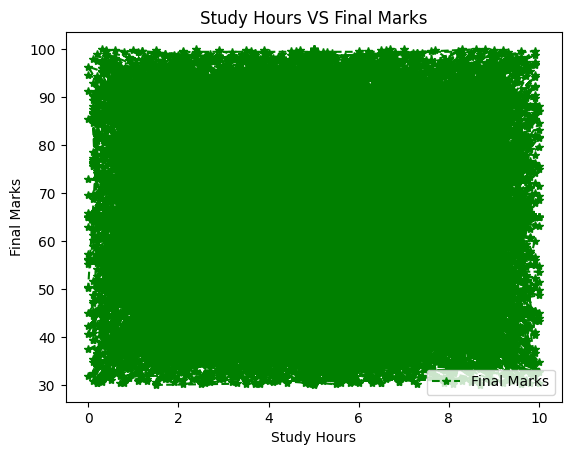

In [16]:
plt.plot(df.Study_Hours,df.Final_Marks,"g*--")
plt.title("Study Hours VS Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.legend(["Final Marks"])
plt.show()

##Bar Chart – Attendance vs Average Marks

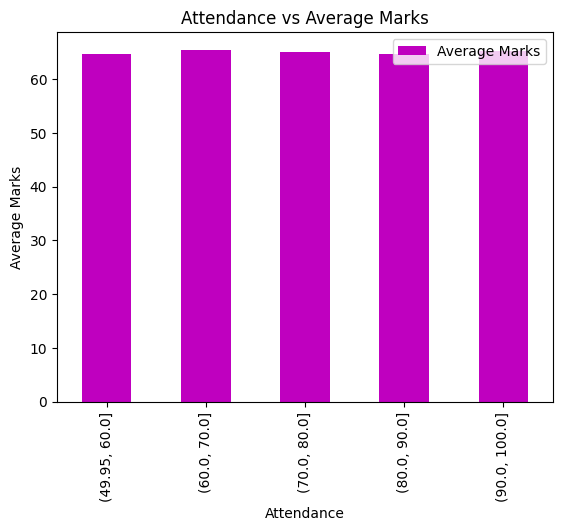

In [17]:
attendance_avg.plot(kind="bar", color="m")
plt.title("Attendance vs Average Marks")
plt.xlabel("Attendance")
plt.ylabel("Average Marks")
plt.legend(["Average Marks"])
plt.show()

##Histogram – Final Marks Distribution

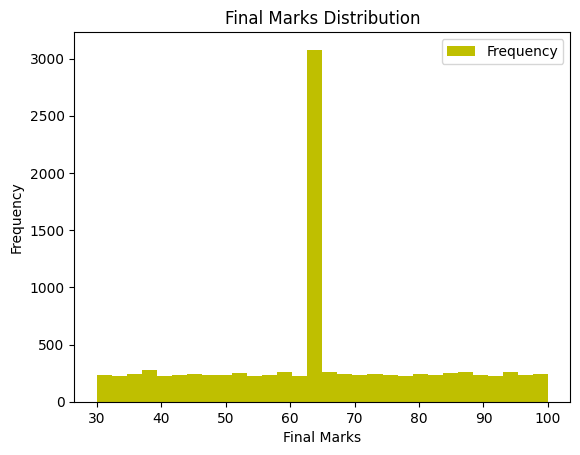

In [18]:
plt.hist(df.Final_Marks, bins=30, color="y")
plt.title("Final Marks Distribution")
plt.xlabel("Final Marks")
plt.ylabel("Frequency")
plt.legend(["Frequency"])
plt.show()

##Scatter Plot – Study Hours vs Final Marks

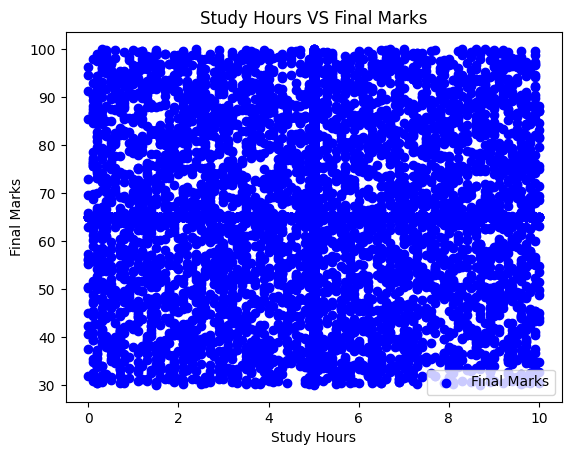

In [19]:
plt.scatter(df.Study_Hours,df.Final_Marks,color="b")
plt.title("Study Hours VS Final Marks")
plt.xlabel("Study Hours")
plt.ylabel("Final Marks")
plt.legend(["Final Marks"])
plt.show()

##Correlation For Making Heatmap

In [20]:
corr = df.corr(numeric_only=True)
corr

,Age,Study_Hours,Attendance,Quiz_Marks,Final_Marks
Age,1.000000,0.004880,-0.000383,-0.003294,0.002752
Study_Hours,0.004880,1.000000,-0.004122,0.001705,0.008970
Attendance,-0.000383,-0.004122,1.000000,0.009641,0.004442
Quiz_Marks,-0.003294,0.001705,0.009641,1.000000,-0.003202
Final_Marks,0.002752,0.008970,0.004442,-0.003202,1.000000


##Heatmap – Correlation Matrix

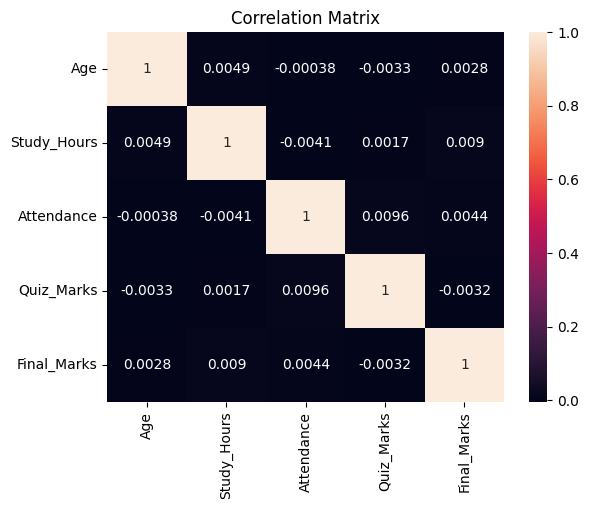

In [21]:
sns.heatmap(corr,annot=True)
plt.title("Correlation Matrix")
plt.show()

#**Statistics & Probability**

##Mean, Median, Mode For all data

In [22]:
mean_value_all = df.mean(numeric_only=True)
mean_value_all

,0
Age,19.98960
Study_Hours,5.00459
Attendance,74.84835
Quiz_Marks,9.95996
Final_Marks,65.00327


In [23]:
median_value_all = df.median(numeric_only=True)
median_value_all

,0
Age,20.0
Study_Hours,5.0
Attendance,74.8
Quiz_Marks,10.0
Final_Marks,64.9


In [24]:
mode_value_all = df.mode()
mode_value_all

,Name,Age,Study_Hours,Attendance,Quiz_Marks,Final_Marks
0,Student_1,24.0,5.0,74.8,10.0,64.9
1,Student_10,NaN,NaN,NaN,NaN,NaN
2,Student_100,NaN,NaN,NaN,NaN,NaN
3,Student_1000,NaN,NaN,NaN,NaN,NaN
4,Student_10000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
9995,Student_9995,NaN,NaN,NaN,NaN,NaN
9996,Student_9996,NaN,NaN,NaN,NaN,NaN
9997,Student_9997,NaN,NaN,NaN,NaN,NaN
9998,Student_9998,NaN,NaN,NaN,NaN,NaN


##Compute Mean, Median, Mode.

In [25]:
mean_Final_marks = df.Final_Marks.mean()
mean_Final_marks

np.float64(65.00327)

In [26]:
median_Final_marks = df.Final_Marks.median()
median_Final_marks

64.9

In [27]:
mode_Final_marks = df.Final_Marks.mode()
mode_Final_marks

,Final_Marks
0,64.9


##Variance and Standard Deviation for all data

In [28]:
variance_all = df.var(numeric_only=True)
variance_all

,0
Age,10.008293
Study_Hours,5.645306
Attendance,135.014061
Quiz_Marks,23.182289
Final_Marks,292.907401


In [29]:
Standard_deviation_all = df.std(numeric_only=True)
Standard_deviation_all

,0
Age,3.163589
Study_Hours,2.375985
Attendance,11.619555
Quiz_Marks,4.814799
Final_Marks,17.114538


##Compute Variance and Standard Deviation.

In [30]:
varience_Final_marks = df.Final_Marks.var()
varience_Final_marks

292.90740104721147

In [31]:
Standard_Final_marks = df.Final_Marks.std()
Standard_Final_marks

17.114537710590124

##Find Correlation between variables.

In [32]:
corr,p_value = stats.pearsonr(df.Study_Hours,df.Final_Marks)
print("Correlation: ",corr)
print("p_value: ",p_value)

Correlation:  0.008969713784517861
p_value:  0.3697843990548223


##Perform a Hypothesis Test (P-Value) to check if study hours affect marks.

In [33]:
corr, p_value = stats.pearsonr(df.Study_Hours,df.Final_Marks)
print("Corr: ",corr)
print("p_value: ",p_value)
alpha = 0.05
if p_value < alpha:
  print("Reject the null hypothesis - Study Hours significantly affect Final Marks")
else:
  print("Fail to reject null hypothesis - Study Hours don't significantly affect Final Marks")

Corr:  0.008969713784517861
p_value:  0.3697843990548223
Fail to reject null hypothesis - Study Hours don't significantly affect Final Marks


##Calculate the Probability of Passing (Marks ≥ 50).

In [34]:
pass_probability = (df.Final_Marks >= 50).mean()
pass_probability

np.float64(0.7974)

In [35]:
print("Correlation: ",df["Study_Hours"].corr(df["Final_Marks"]))

Correlation:  0.008969713784517868
